<img src = "https://i.imgur.com/XoRDxQJ.png" align = "center">

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
%matplotlib inline

In [18]:
dataset = pd.read_csv(r'C:\Users\Brilly\Downloads\IMDB Dataset.csv')

In [19]:
# If you store the dataset just in My Drive, use the path below
# dataset = pd.read_csv("/content/drive/My Drive/IMDB Dataset.csv")

In [20]:
dataset.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [21]:
dataset.shape

(50000, 2)

In [22]:
features = dataset['review']
labels = dataset['sentiment']

In [23]:
processed_features = []

for sentence in range(0, len(features)):
    # Remove all the special characters
    processed_feature = re.sub(r'\W', ' ', str(features[sentence]))

    # remove all single characters
    processed_feature= re.sub(r'\s+[a-zA-Z]\s+', ' ', processed_feature)

    # Remove single characters from the start
    processed_feature = re.sub(r'^[a-zA-Z]\s+', '', processed_feature)

    # Substituting multiple spaces with single space
    processed_feature = re.sub(r'\s+', ' ', processed_feature, flags=re.I)

    # Removing prefixed 'b'
    processed_feature = re.sub(r'^b\s+', '', processed_feature)

    # Converting to Lowercase
    processed_feature = processed_feature.lower()

    processed_features.append(processed_feature)

In [24]:
features[:5]

0    One of the other reviewers has mentioned that ...
1    A wonderful little production. <br /><br />The...
2    I thought this was a wonderful way to spend ti...
3    Basically there's a family where a little boy ...
4    Petter Mattei's "Love in the Time of Money" is...
Name: review, dtype: object

In [25]:
processed_features[:5]

['one of the other reviewers has mentioned that after watching just 1 oz episode you ll be hooked they are right as this is exactly what happened with me br br the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word br br it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to many aryans muslims gangstas latinos christians italians irish and more so scuffles death stares dodgy dealings and shady agreements are never far away br br would say the main appeal of the show is due to the fact that it goes where other shows wouldn dare 

In [26]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Brilly\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer (max_features=2500, min_df=7, max_df=0.8, stop_words=stopwords.words('english'))
processed_features = vectorizer.fit_transform(processed_features).toarray()

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(processed_features, labels, test_size=0.2, random_state=0)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

### Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression

# Tambahkan parameter solver='liblinear'
logit = LogisticRegression(C=0.2, dual=True, solver='liblinear')
logit.fit(X_train, y_train)
predictions = logit.predict(X_test)

In [32]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))
print("Accuracy: {0:.4f}".format(accuracy_score(y_test, predictions)))

Confusion Matrix:
[[4323  712]
 [ 576 4389]]
              precision    recall  f1-score   support

    negative       0.88      0.86      0.87      5035
    positive       0.86      0.88      0.87      4965

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

Accuracy: 0.8712


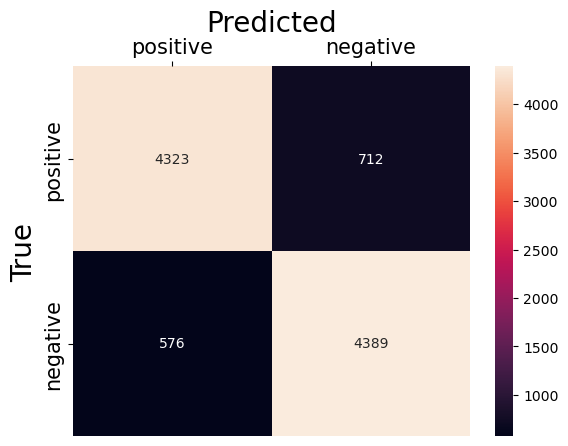

In [33]:
matrix = confusion_matrix(y_test, predictions)
ax= plt.subplot()
sns.heatmap(matrix, annot=True, ax = ax, fmt = 'g'); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticklabels(['positive', 'negative'], fontsize = 15)
ax.xaxis.tick_top()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(['positive', 'negative'], fontsize = 15)
plt.show()

### Naive Bayes

In [34]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
predictions = mnb.predict(X_test)

In [35]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))
print("Accuracy: {0:.4f}".format(accuracy_score(y_test, predictions)))

Confusion Matrix:
[[4217  818]
 [ 677 4288]]
              precision    recall  f1-score   support

    negative       0.86      0.84      0.85      5035
    positive       0.84      0.86      0.85      4965

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Accuracy: 0.8505


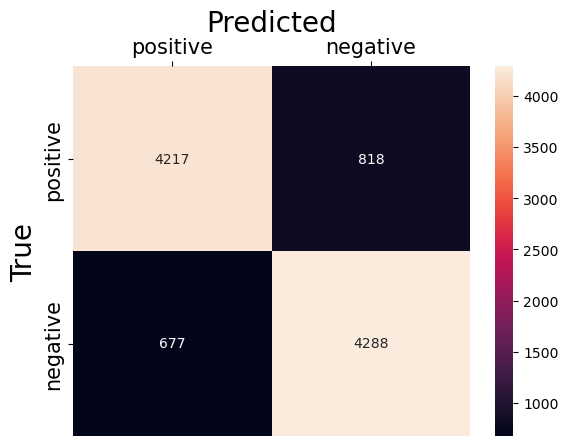

In [36]:
matrix = confusion_matrix(y_test, predictions)
ax= plt.subplot()
sns.heatmap(matrix, annot=True, ax = ax, fmt = 'g'); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticklabels(['positive', 'negative'], fontsize = 15)
ax.xaxis.tick_top()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(['positive', 'negative'], fontsize = 15)
plt.show()

### LinearSVC

In [37]:
svc = LinearSVC()
svc.fit(X_train, y_train)
predictions = svc.predict(X_test)

In [38]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))
print("Accuracy: {0:.4f}".format(accuracy_score(y_test, predictions)))

Confusion Matrix:
[[4365  670]
 [ 571 4394]]
              precision    recall  f1-score   support

    negative       0.88      0.87      0.88      5035
    positive       0.87      0.88      0.88      4965

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Accuracy: 0.8759


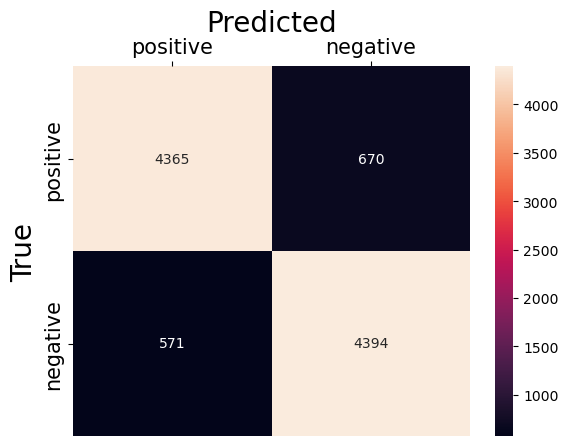

In [39]:
matrix = confusion_matrix(y_test, predictions)
ax= plt.subplot()
sns.heatmap(matrix, annot=True, ax = ax, fmt = 'g'); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticklabels(['positive', 'negative'], fontsize = 15)
ax.xaxis.tick_top()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(['positive', 'negative'], fontsize = 15)
plt.show()

# Modidikasi Kode Sentimen Analisis

## Nama: Brilly Jalu Kumara Biseka

## NIM: 25917018

# Logistic Regression Tuned

In [40]:
print("\n--- 2. LOGISTIC REGRESSION (TUNED) ---")
# Menggunakan solver 'lbfgs' dan C=2.0 untuk performa yang lebih baik pada data besar
logit_tuned = LogisticRegression(C=2.0, max_iter=1000, solver='lbfgs', random_state=42)
logit_tuned.fit(X_train, y_train)
predictions_tuned = logit_tuned.predict(X_test)



--- 2. LOGISTIC REGRESSION (TUNED) ---


In [41]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_tuned))
print(classification_report(y_test, predictions_tuned, target_names=['negative', 'positive']))
print("Accuracy: {0:.4f}".format(accuracy_score(y_test, predictions_tuned)))


Confusion Matrix:
[[4383  652]
 [ 546 4419]]
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      5035
    positive       0.87      0.89      0.88      4965

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Accuracy: 0.8802


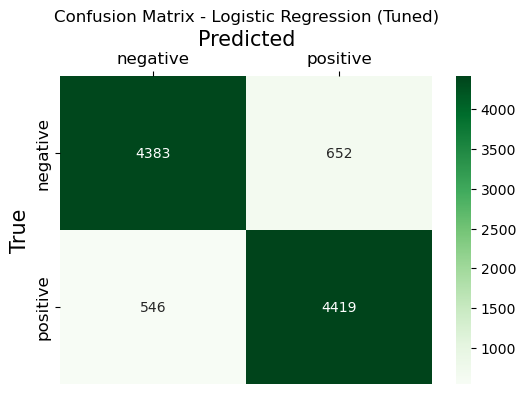

In [42]:
plt.figure(figsize=(6, 4))
matrix_tuned = confusion_matrix(y_test, predictions_tuned)
ax = plt.subplot()
sns.heatmap(matrix_tuned, annot=True, ax=ax, fmt='g', cmap='Greens')
ax.set_title('Confusion Matrix - Logistic Regression (Tuned)')
ax.set_xlabel('Predicted', fontsize=15)
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
ax.xaxis.tick_top()
ax.set_ylabel('True', fontsize=15)
ax.yaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
plt.show()

# Naive Bayes Tuned

In [45]:
print("\n--- 3. MULTINOMIAL NAIVE BAYES ---")
from sklearn.naive_bayes import MultinomialNB

# TUNING: Menurunkan nilai alpha (Laplace smoothing) dari 1.0 menjadi 0.1 
# agar model lebih akurat dalam mengklasifikasikan fitur TF-IDF
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)
predictions_nb = nb_model.predict(X_test)




--- 3. MULTINOMIAL NAIVE BAYES ---


Confusion Matrix:
[[4212  823]
 [ 671 4294]]
              precision    recall  f1-score   support

    negative       0.86      0.84      0.85      5035
    positive       0.84      0.86      0.85      4965

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Accuracy: 0.8506


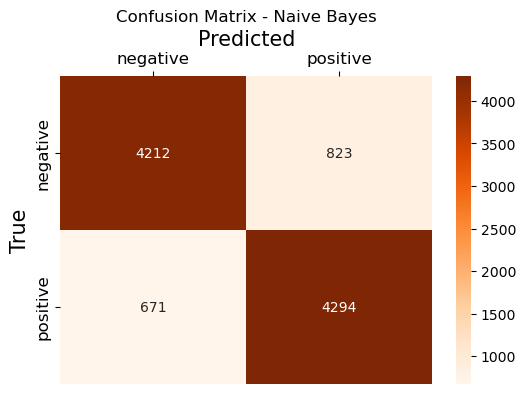

In [46]:

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_nb))
print(classification_report(y_test, predictions_nb, target_names=['negative', 'positive']))
print("Accuracy: {0:.4f}".format(accuracy_score(y_test, predictions_nb)))

plt.figure(figsize=(6, 4))
matrix_nb = confusion_matrix(y_test, predictions_nb)
ax = plt.subplot()
sns.heatmap(matrix_nb, annot=True, ax=ax, fmt='g', cmap='Oranges')
ax.set_title('Confusion Matrix - Naive Bayes')
ax.set_xlabel('Predicted', fontsize=15)
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
ax.xaxis.tick_top()
ax.set_ylabel('True', fontsize=15)
ax.yaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
plt.show()

# LinierSVC Tuned

In [51]:
print("\n--- 4. LINEAR SVC ---")
from sklearn.svm import LinearSVC


# TUNING: 
# 1. Menurunkan C=0.5 agar model tidak overfitting pada data teks.
# 2. dual=False digunakan karena jumlah sampel (baris) lebih banyak dari fitur (kolom).
svc_model = LinearSVC(C=0.5, dual=False, max_iter=2000, random_state=42)
svc_model.fit(X_train, y_train)
predictions_svc = svc_model.predict(X_test)


--- 4. LINEAR SVC ---


Confusion Matrix:
[[4381  654]
 [ 561 4404]]
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      5035
    positive       0.87      0.89      0.88      4965

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Accuracy: 0.8785


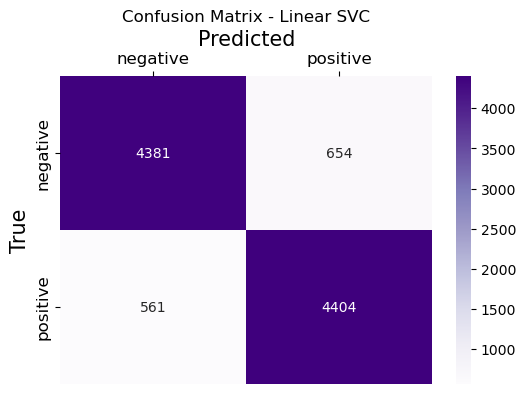

In [52]:

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_svc))
print(classification_report(y_test, predictions_svc, target_names=['negative', 'positive']))
print("Accuracy: {0:.4f}".format(accuracy_score(y_test, predictions_svc)))

plt.figure(figsize=(6, 4))
matrix_svc = confusion_matrix(y_test, predictions_svc)
ax = plt.subplot()
sns.heatmap(matrix_svc, annot=True, ax=ax, fmt='g', cmap='Purples')
ax.set_title('Confusion Matrix - Linear SVC')
ax.set_xlabel('Predicted', fontsize=15)
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
ax.xaxis.tick_top()
ax.set_ylabel('True', fontsize=15)
ax.yaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
plt.show()

# DECISION TREE CLASSIFIER

In [49]:
from sklearn.tree import DecisionTreeClassifier

# Membatasi max_depth agar model tidak menghafal data terlalu berlebihan (overfitting) 
# dan proses training tidak terlalu lama pada data teks yang sparse
dt_model = DecisionTreeClassifier(max_depth=100, random_state=42)
dt_model.fit(X_train, y_train)
predictions_dt = dt_model.predict(X_test)


Confusion Matrix:
[[3569 1466]
 [1387 3578]]
              precision    recall  f1-score   support

    negative       0.72      0.71      0.71      5035
    positive       0.71      0.72      0.71      4965

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000

Accuracy: 0.7147


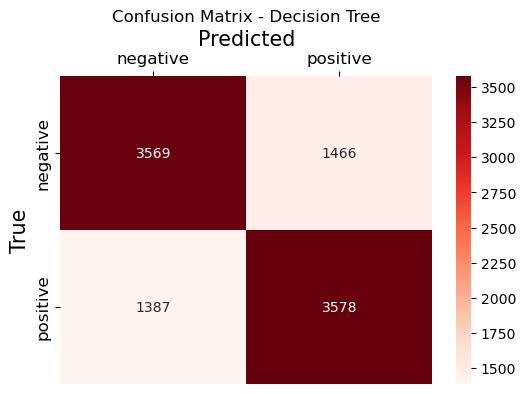

In [50]:

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_dt))
print(classification_report(y_test, predictions_dt, target_names=['negative', 'positive']))
print("Accuracy: {0:.4f}".format(accuracy_score(y_test, predictions_dt)))

plt.figure(figsize=(6, 4))
matrix_dt = confusion_matrix(y_test, predictions_dt)
ax = plt.subplot()
sns.heatmap(matrix_dt, annot=True, ax=ax, fmt='g', cmap='Reds')
ax.set_title('Confusion Matrix - Decision Tree')
ax.set_xlabel('Predicted', fontsize=15)
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
ax.xaxis.tick_top()
ax.set_ylabel('True', fontsize=15)
ax.yaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
plt.show()

# RANDOM FOREST CLASSIFIER

In [53]:
print("\n--- 6. RANDOM FOREST CLASSIFIER ---")
from sklearn.ensemble import RandomForestClassifier

# n_jobs=-1 digunakan untuk memakai seluruh core CPU komputer agar proses lebih cepat
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)
predictions_rf = rf_model.predict(X_test)


--- 6. RANDOM FOREST CLASSIFIER ---


Confusion Matrix:
[[4291  744]
 [ 829 4136]]
              precision    recall  f1-score   support

    negative       0.84      0.85      0.85      5035
    positive       0.85      0.83      0.84      4965

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000

Accuracy: 0.8427


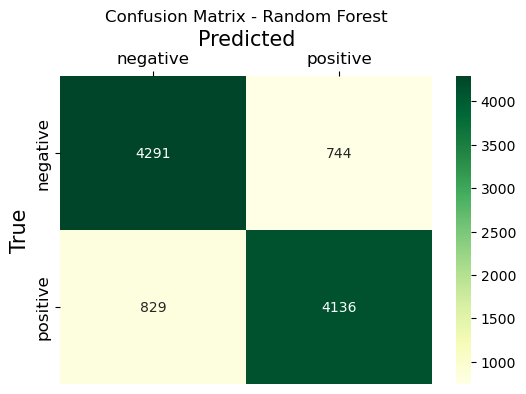

In [54]:

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_rf))
print(classification_report(y_test, predictions_rf, target_names=['negative', 'positive']))
print("Accuracy: {0:.4f}".format(accuracy_score(y_test, predictions_rf)))

plt.figure(figsize=(6, 4))
matrix_rf = confusion_matrix(y_test, predictions_rf)
ax = plt.subplot()
sns.heatmap(matrix_rf, annot=True, ax=ax, fmt='g', cmap='YlGn')
ax.set_title('Confusion Matrix - Random Forest')
ax.set_xlabel('Predicted', fontsize=15)
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
ax.xaxis.tick_top()
ax.set_ylabel('True', fontsize=15)
ax.yaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
plt.show()

# SGD CLASSIFIER (Stochastic Gradient Descent)

In [55]:
from sklearn.linear_model import SGDClassifier

# TUNING: Mengubah fungsi loss ke 'modified_huber' dan menggunakan penalti 'elasticnet'
# Penyesuaian alpha ke 1e-5 agar model bisa mendapatkan pola yang lebih baik tanpa terlalu diatur.
sgd_model = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=1e-5, max_iter=1000, tol=1e-3, random_state=42)
sgd_model.fit(X_train, y_train)
predictions_sgd = sgd_model.predict(X_test)

Confusion Matrix:
[[4253  782]
 [ 483 4482]]
              precision    recall  f1-score   support

    negative       0.90      0.84      0.87      5035
    positive       0.85      0.90      0.88      4965

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

Accuracy: 0.8735


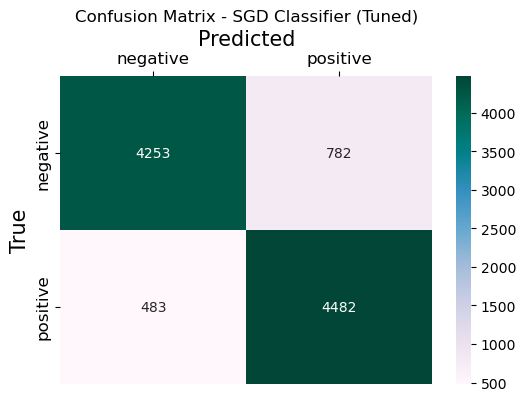

In [56]:

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_sgd))
print(classification_report(y_test, predictions_sgd, target_names=['negative', 'positive']))
print("Accuracy: {0:.4f}".format(accuracy_score(y_test, predictions_sgd)))

plt.figure(figsize=(6, 4))
matrix_sgd = confusion_matrix(y_test, predictions_sgd)
ax = plt.subplot()
sns.heatmap(matrix_sgd, annot=True, ax=ax, fmt='g', cmap='PuBuGn')
ax.set_title('Confusion Matrix - SGD Classifier (Tuned)')
ax.set_xlabel('Predicted', fontsize=15)
ax.xaxis.set_label_position('top')
ax.xaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
ax.xaxis.tick_top()
ax.set_ylabel('True', fontsize=15)
ax.yaxis.set_ticklabels(['negative', 'positive'], fontsize=12)
plt.show()